# Generative Models for Digit Classification
## Exploring Gaussian-based Generative Models on MNIST

In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Setup Instructions

Before running this notebook:
1. Download MNIST dataset: https://www.kaggle.com/datasets/hojjatk/mnist-dataset/data
2. Extract to a folder named 'mnist' in the parent directory
3. Ensure cs771 module is available with plotData and utils modules
4. Place this notebook, mnist folder, and cs771 module in the same parent directory

In [6]:
import numpy as np
from numpy import random as rng
from numpy import linalg as la
import random
from cs771 import plotData as plot_utils
from cs771 import utils
import struct
from array import array
from os.path import join
import matplotlib.pyplot as plt

## Data Loading Module
MNIST dataset reader - parses binary format files

In [7]:
class DigitDatasetLoader:
    """Load MNIST digit dataset from binary files"""
    
    def __init__(self, train_img_path, train_lbl_path, test_img_path, test_lbl_path):
        self.train_images_file = train_img_path
        self.train_labels_file = train_lbl_path
        self.test_images_file = test_img_path
        self.test_labels_file = test_lbl_path
    
    def parse_binary_files(self, img_path, lbl_path):
        """Parse MNIST binary format files"""
        # Read labels
        labels_data = []
        with open(lbl_path, 'rb') as f:
            magic_num, count = struct.unpack(">II", f.read(8))
            if magic_num != 2049:
                raise ValueError(f'Label magic number mismatch: expected 2049, got {magic_num}')
            labels_data = array("B", f.read())
        
        # Read images
        with open(img_path, 'rb') as f:
            magic_num, count, rows, cols = struct.unpack(">IIII", f.read(16))
            if magic_num != 2051:
                raise ValueError(f'Image magic number mismatch: expected 2051, got {magic_num}')
            image_data = array("B", f.read())
        
        # Reconstruct images as 28x28 arrays
        images = []
        for idx in range(count):
            images.append([0] * rows * cols)
        
        for idx in range(count):
            img_array = np.array(image_data[idx * rows * cols:(idx + 1) * rows * cols])
            img_array = img_array.reshape(rows, cols)
            images[idx][:] = img_array
        
        return images, labels_data
    
    def load_all(self):
        """Load complete training and test datasets"""
        train_images, train_labels = self.parse_binary_files(self.train_images_file, self.train_labels_file)
        test_images, test_labels = self.parse_binary_files(self.test_images_file, self.test_labels_file)
        return (train_images, train_labels), (test_images, test_labels)

In [8]:
# Setup file paths for MNIST dataset
data_dir = 'mnist/'
train_img_file = join(data_dir, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
train_lbl_file = join(data_dir, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_img_file = join(data_dir, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_lbl_file = join(data_dir, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

# Load dataset
loader = DigitDatasetLoader(train_img_file, train_lbl_file, test_img_file, test_lbl_file)
((train_images, train_labels), (test_images, test_labels)) = loader.load_all()

# Convert to numpy arrays
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

# Reshape training images
train_data = np.zeros((len(train_images), 28, 28))
for i in range(len(train_images)):
    train_data[i, :] = np.concatenate(train_images[i]).reshape((28, 28))

# Reshape test images
test_data = np.zeros((len(test_images), 28, 28))
for i in range(len(test_images)):
    test_data[i, :] = np.concatenate(test_images[i]).reshape((28, 28))

# Normalize pixel values
train_data = train_data / 256.0

num_samples = train_data.shape[0]
image_shape = train_data.shape[1:]

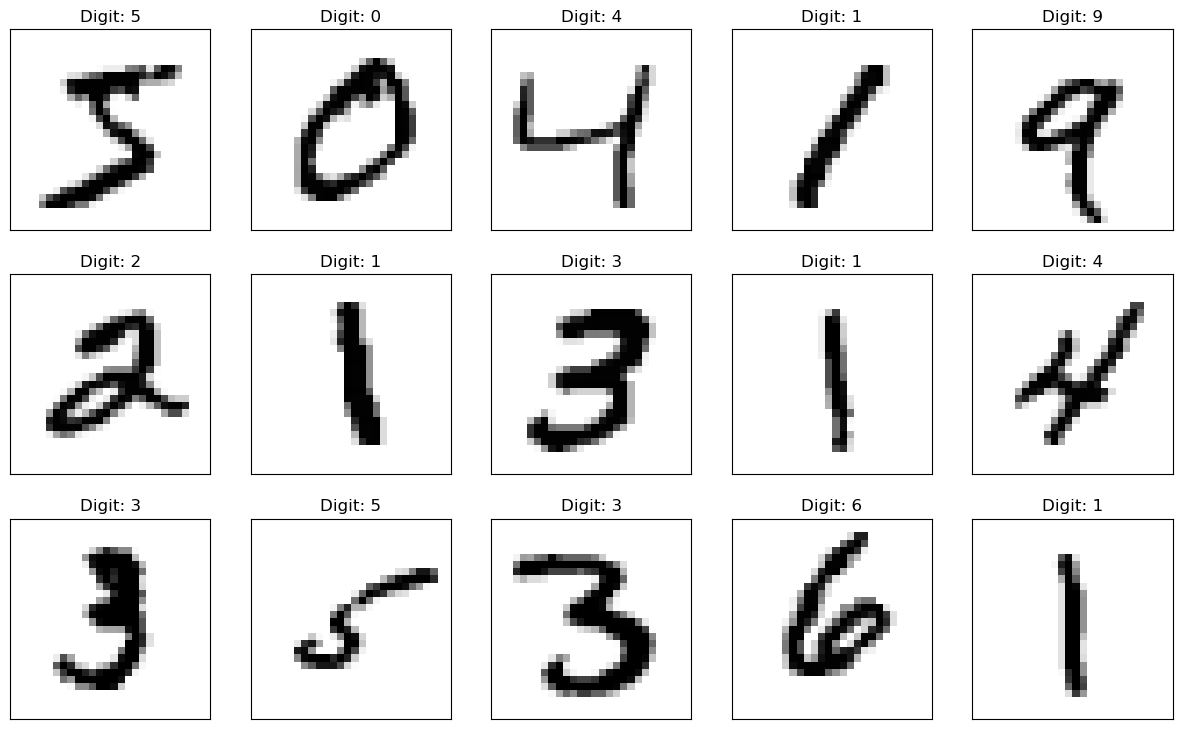

In [9]:
# Visualize some training samples
rows, cols = 3, 5
fig, axes = plot_utils.getFigList(rows, cols)
sample_labels = [f"Digit: {train_labels[i]}" for i in range(rows * cols)]
plot_utils.showImagesNoAxes(axes, train_data[:rows*cols], rows, cols, labelList=sample_labels)

## Part 1: Single Gaussian Models

### Creating a Subset Dataset
To explore different Gaussian models, we'll create a simpler dataset containing only digits 0 and 4

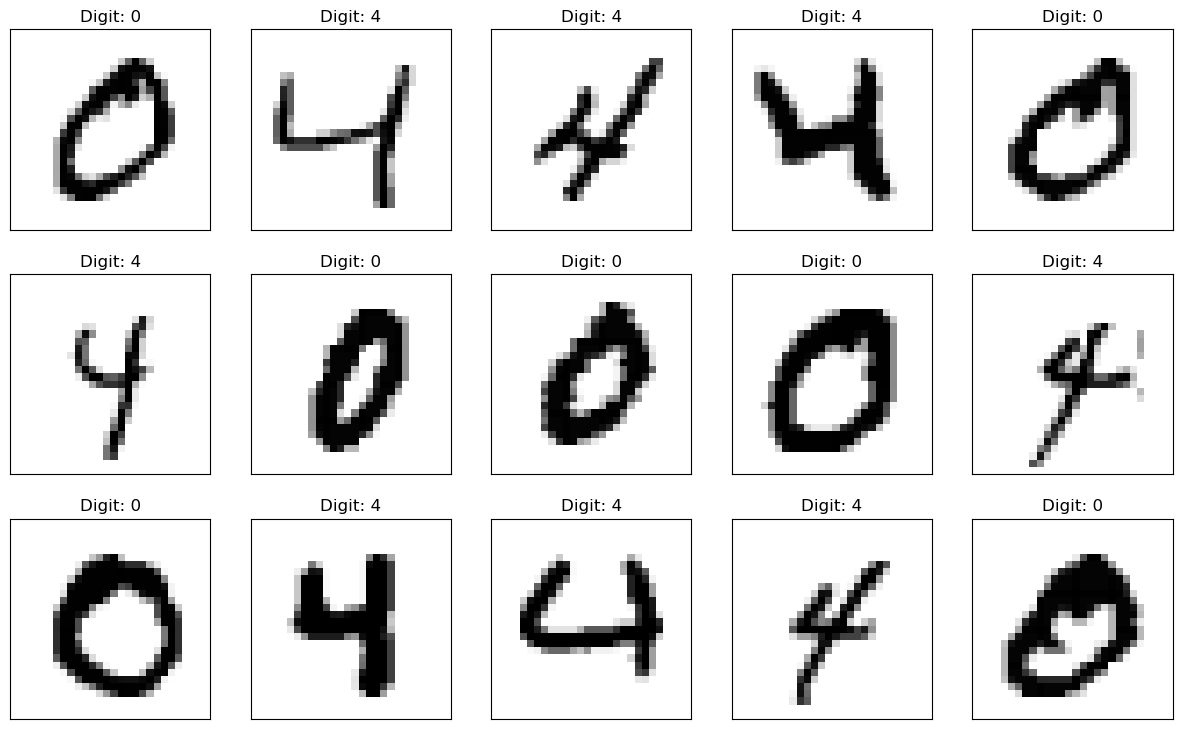

In [10]:
def extract_digit_subset(digit_list):
    """Extract subset of training data containing only specified digits"""
    mask = np.isin(train_labels, digit_list)
    return train_data[mask][:][:], train_labels[mask]

# Create subset with digits 0 and 4
selected_digits = np.array([0, 4])
subset_images, subset_labels = extract_digit_subset(selected_digits)

# Flatten images to 1D vectors
n_samples = subset_images.shape[0]
feature_dim = np.prod(subset_images.shape[1:])
subset_flat = subset_images.reshape(n_samples, feature_dim)

# Visualize subset
fig2, axes2 = plot_utils.getFigList(rows, cols)
subset_labels_str = [f"Digit: {subset_labels[i]}" for i in range(rows * cols)]
plot_utils.showImagesNoAxes(axes2, subset_flat[:rows*cols], rows, cols, resize=True, imShape=image_shape, labelList=subset_labels_str)

### Attempt 1: Standard Gaussian (Identity Covariance) - Why This Fails

We start with the simplest model: a Gaussian with identity covariance. This assumes all features (pixels) are completely independent.

**Why this is bad:**
- The mean image will be a "ghostly superimposition" of both 0 and 4 digits since they're mixed together
- The identity covariance means we're NOT learning any structure about how pixels correlate
- Generated samples will be extremely noisy and unusable as they don't capture the actual digit patterns
- This shows that independence assumption is too restrictive for image data

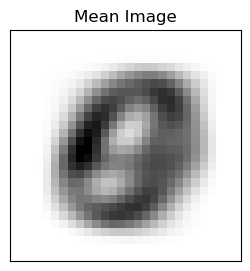

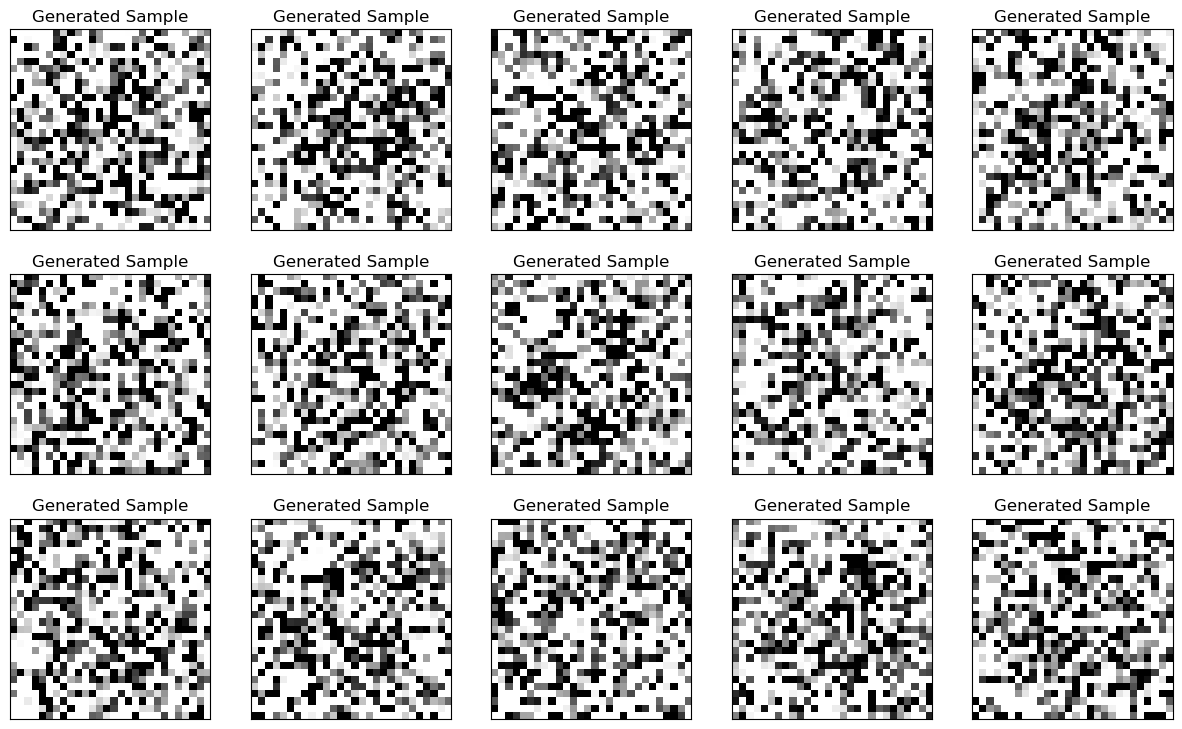

In [11]:
def compute_mean_vector(X):
    """Compute mean of data"""
    return np.mean(X, axis=0)

def clip_values(X, min_val=0, max_val=1):
    """Clip pixel values to valid range"""
    return np.clip(X, min_val, max_val)

# Fit mean to subset
mean_vector = compute_mean_vector(subset_flat)

# Visualize mean image
fig3, axes3 = plot_utils.getFigList(1, 1)
plot_utils.showImagesNoAxes(axes3, mean_vector[np.newaxis, :], 1, 1, resize=True, imShape=image_shape, labelList=["Mean Image"])

# Generate synthetic samples from standard Gaussian
n_samples_gen = rows * cols
fig4, axes4 = plot_utils.getFigList(rows, cols)
sample_labels = ["Generated Sample" for i in range(n_samples_gen)]

synthetic_samples = rng.multivariate_normal(mean_vector, np.eye(feature_dim), size=n_samples_gen, check_valid="raise")
synthetic_samples = clip_values(synthetic_samples)
plot_utils.showImagesNoAxes(axes4, synthetic_samples, rows, cols, resize=True, imShape=image_shape, labelList=sample_labels)

### Attempt 2: Full Covariance Gaussian - Why This Is Better

Now we learn both the mean and covariance matrix. This allows us to model correlations between pixel values.

**Why this improves things significantly:**
- Learning covariance structure is VITAL for generative models
- The samples now show some recognizable digit patterns (0 and 4 shapes)
- Still not perfect because one Gaussian tries to model TWO different digits with different appearances
- The covariance captures relationships: "when pixel A is dark, pixel B tends to be dark too" (or light)
- However, even with better covariance, the results are still "haphazardly placed" shapes - one Gaussian is fundamentally not enough

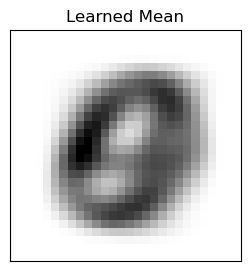

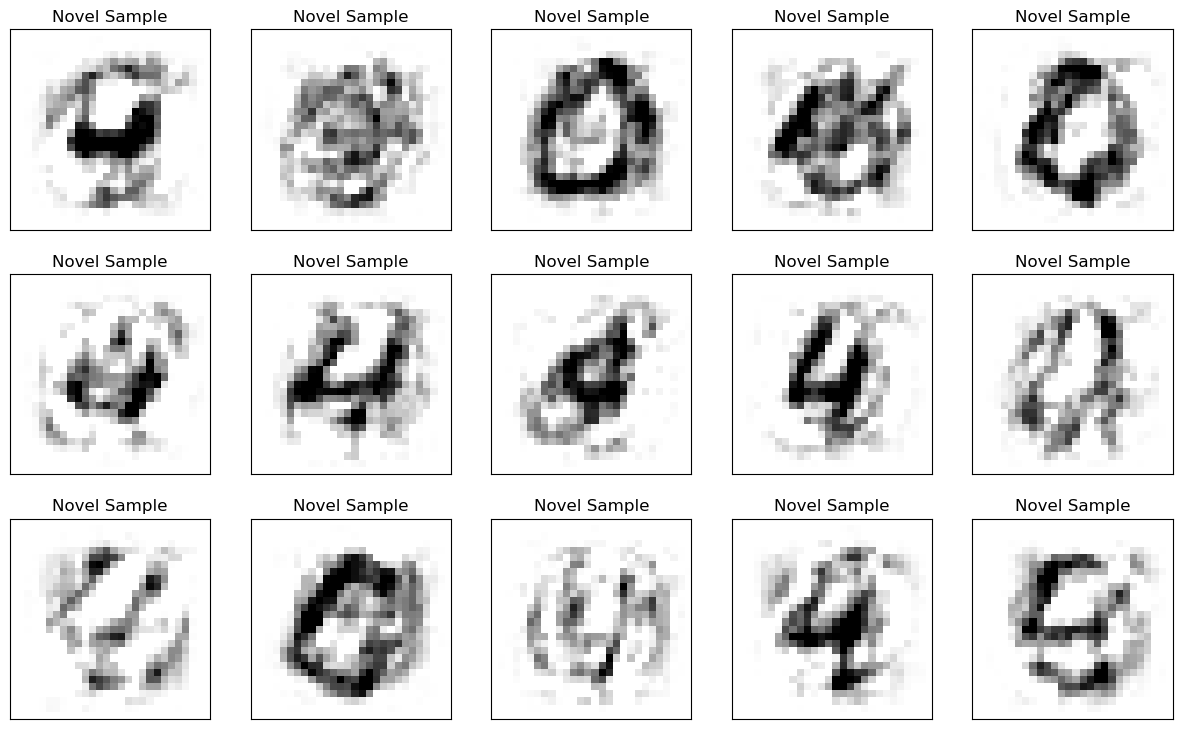

In [12]:
def fit_gaussian_model(X):
    """Fit Gaussian model with full covariance"""
    n_samples = X.shape[0]
    feature_dim = X.shape[1]
    
    # Compute mean
    mean = np.mean(X, axis=0)
    
    # Center the data
    centered_X = X - mean
    
    # Compute covariance
    covariance = (1/n_samples) * (centered_X.T).dot(centered_X)
    
    return mean, covariance

# Fit Gaussian model
learned_mean, learned_cov = fit_gaussian_model(subset_flat)

# Visualize learned mean
fig5, axes5 = plot_utils.getFigList(1, 1)
plot_utils.showImagesNoAxes(axes5, learned_mean[np.newaxis, :], 1, 1, resize=True, imShape=image_shape, labelList=["Learned Mean"])

# Generate samples from learned Gaussian
fig6, axes6 = plot_utils.getFigList(rows, cols)
sample_labels = ["Novel Sample" for i in range(n_samples_gen)]

generated_samples = rng.multivariate_normal(learned_mean, learned_cov, size=n_samples_gen, check_valid="raise")
generated_samples = clip_values(generated_samples)
plot_utils.showImagesNoAxes(axes6, generated_samples, rows, cols, resize=True, imShape=image_shape, labelList=sample_labels)

## Part 2: Mixture of Gaussians with EM Algorithm

### Why Single Gaussian Fails: The Problem of Diversity

Since the dataset contains two different digits (0 and 4) with significantly different appearances, a single Gaussian cannot capture this diversity. The fundamental issue:

- A single Gaussian produces samples that look like a "blur" or superposition of both digits
- We need AT LEAST 2 components to handle different digit types
- But even WITHIN a single digit, there are variations: upright 4 vs slanted 4, thick 0 vs thin 0
- So we actually need more components (e.g., 4-10) to capture these writing style variations

### The Solution: Mixture of Gaussians with EM

**Key insight:** We assume labels are UNKNOWN (unsupervised learning). Each digit might belong to one of multiple "writing styles". We use:
1. **E-step**: Assign each image to components (with weights/probabilities)
2. **M-step**: Update component parameters based on these assignments
3. This is an iterative process that discovers hidden structure

**Why this works better:**
- Realistic, diverse samples are generated
- No individual sample looks exactly like training samples (they are novel)
- Significantly improved quality compared to single Gaussian attempts
- Can capture style variations within the same digit

**Trade-off:** Too few components → diversity lost. Too many components → overfitting, slow computation, sparse data per component.

In [ ]:
### EM Algorithm Implementation

**Initialization with K-means++:**
- Don't start with random centroids - spread them far apart
- First centroid: random data point
- Each subsequent centroid: the data point farthest from existing centroids
- Why? Avoids getting stuck in bad local optima

In [ ]:
### E-step: Assign Images to Components

In the E-step, compute how much each image "belongs to" each component:
- Compute distance from each image to each component mean
- Images close to component mean → high responsibility for that component
- Images far from component mean → low responsibility
- Normalize so responsibilities sum to 1 (they become weights/probabilities)

### M-step: Update Component Parameters

In the M-step, update the components based on E-step assignments:
- Each component's new mean = weighted average of all images (weights from E-step)
- If a component has few assigned images → keep old mean (avoid empty clusters)
- Covariance update happens once at the end for efficiency

In [ ]:
### Running the EM Algorithm

**Computational shortcuts used (for efficiency):**
- E-step typically requires computing inverse of large covariance matrices (expensive!)
- Shortcut: Approximate covariance by identity matrix in E-step
- We don't use covariance in E-step calculation anyway, so this saves time
- Covariance matrices only updated once at the very end
- Trade-off: Faster training, still learns good components

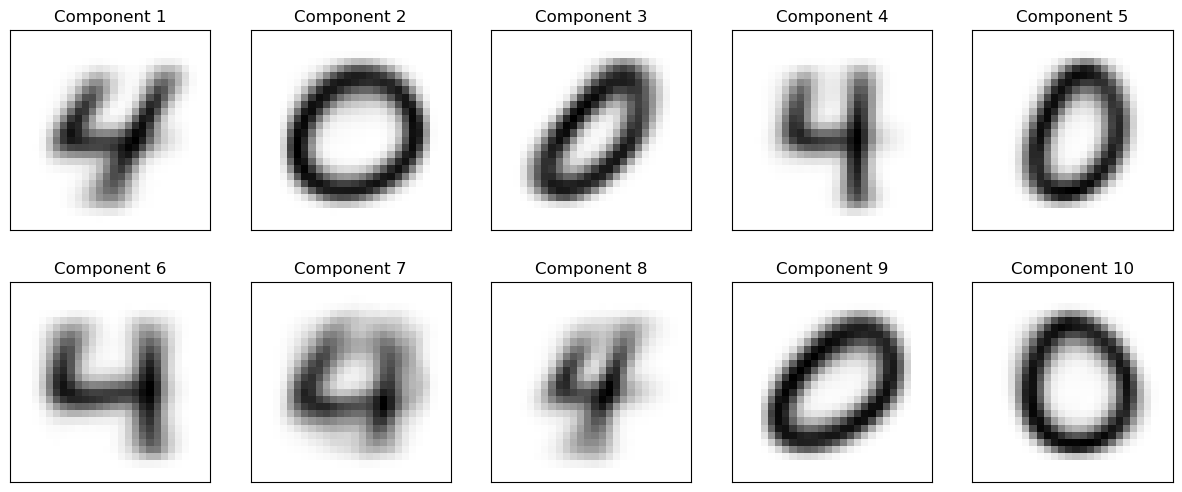

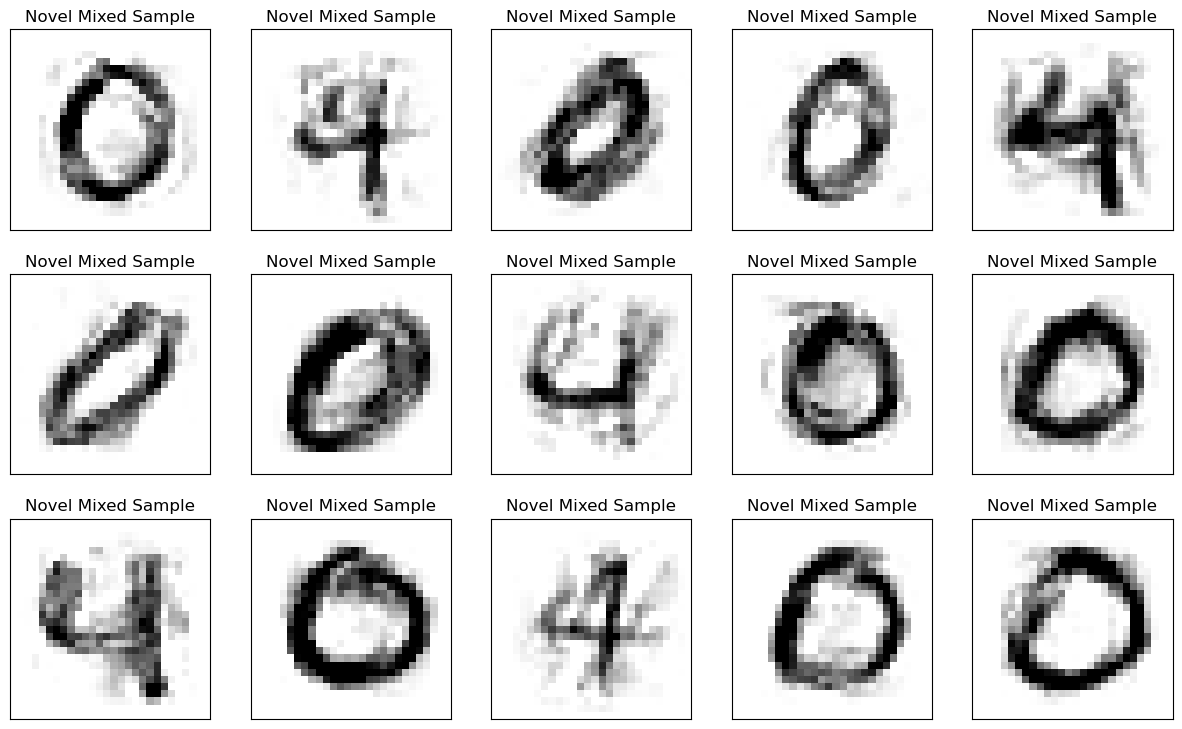

In [16]:
# Visualize mixture components
comp_rows, comp_cols = 2, num_mix_components // 2
fig7, axes7 = plot_utils.getFigList(comp_rows, comp_cols)
comp_labels = [f"Component {k+1}" for k in range(num_mix_components)]
plot_utils.showImagesNoAxes(axes7, mix_means, comp_rows, comp_cols, resize=True, imShape=image_shape, labelList=comp_labels)

# Generate samples from mixture model
fig8, axes8 = plot_utils.getFigList(rows, cols)
mix_samples = np.zeros((rows * cols, feature_dim))
for i in range(rows * cols):
    comp_idx = random.randint(0, num_mix_components - 1)
    mix_samples[i] = rng.multivariate_normal(mix_means[comp_idx], mix_covs[comp_idx], check_valid="raise")

mix_samples = clip_values(mix_samples)
sample_labels = ["Novel Mixed Sample" for i in range(rows * cols)]
plot_utils.showImagesNoAxes(axes8, mix_samples, rows, cols, resize=True, imShape=image_shape, labelList=sample_labels)

## Part 3: The Critical Importance of Modeling Covariances

### Understanding Pixel Correlations

Covariance tells us how different components vary together:
- Do two pixels always have similar intensity? (positive correlation)
- Do they have opposite intensities? (negative correlation)  
- Are they independent? (zero correlation)

For images, correlations are CRUCIAL:
- Adjacent pixels should be similar (local smoothness)
- Structural constraints: certain pixel combinations are impossible (a 7 can't be both upright AND inverted)
- These constraints are only captured in the covariance matrix

### Experiment: Upright vs Inverted 7s

This toy experiment demonstrates WHY covariance matters:

**Spherical Gaussian Problem:**
- Assumes all pixels vary independently
- Cannot encode: "if top-right is dark (upright 7), then bottom-left must be light"
- Cannot learn the anti-correlation between different regions
- Samples look like random noise with no structure

**Full Covariance Solution:**
- Learns that top-right and bottom-left pixels are anti-correlated
- Generates samples that are clearly either upright OR inverted (not mixed)
- Even a SINGLE Gaussian can capture this structure!
- Proof: covariance learning is more important than mixture components in some cases

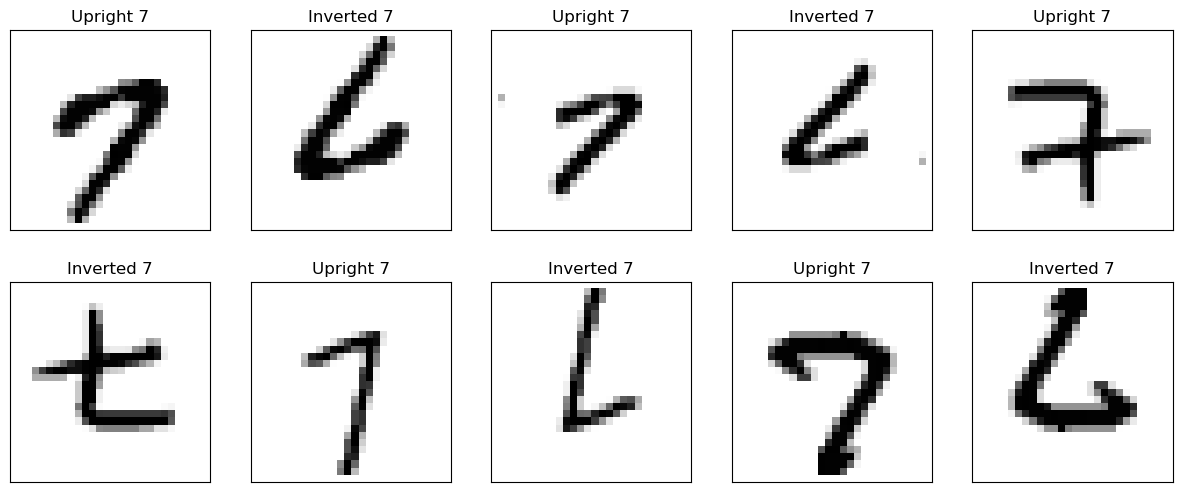

In [17]:
# Create inverted digit dataset
digit_7_imgs, digit_7_labels = extract_digit_subset(np.array([7]))
inverted_imgs = digit_7_imgs[:, ::-1, ::-1]

n_seven = digit_7_imgs.shape[0]
combined_imgs = np.zeros((2 * n_seven, 28, 28))
combined_imgs[::2] = digit_7_imgs
combined_imgs[1::2] = inverted_imgs

# Flatten combined images
combined_flat = combined_imgs.reshape(2 * n_seven, feature_dim)

# Visualize
fig9, axes9 = plot_utils.getFigList(2, 5)
labels_alt = []
for i in range(5):
    labels_alt.append("Upright 7")
    labels_alt.append("Inverted 7")
plot_utils.showImagesNoAxes(axes9, combined_flat[:10], 2, 5, resize=True, imShape=image_shape, labelList=labels_alt)

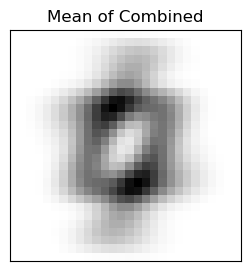

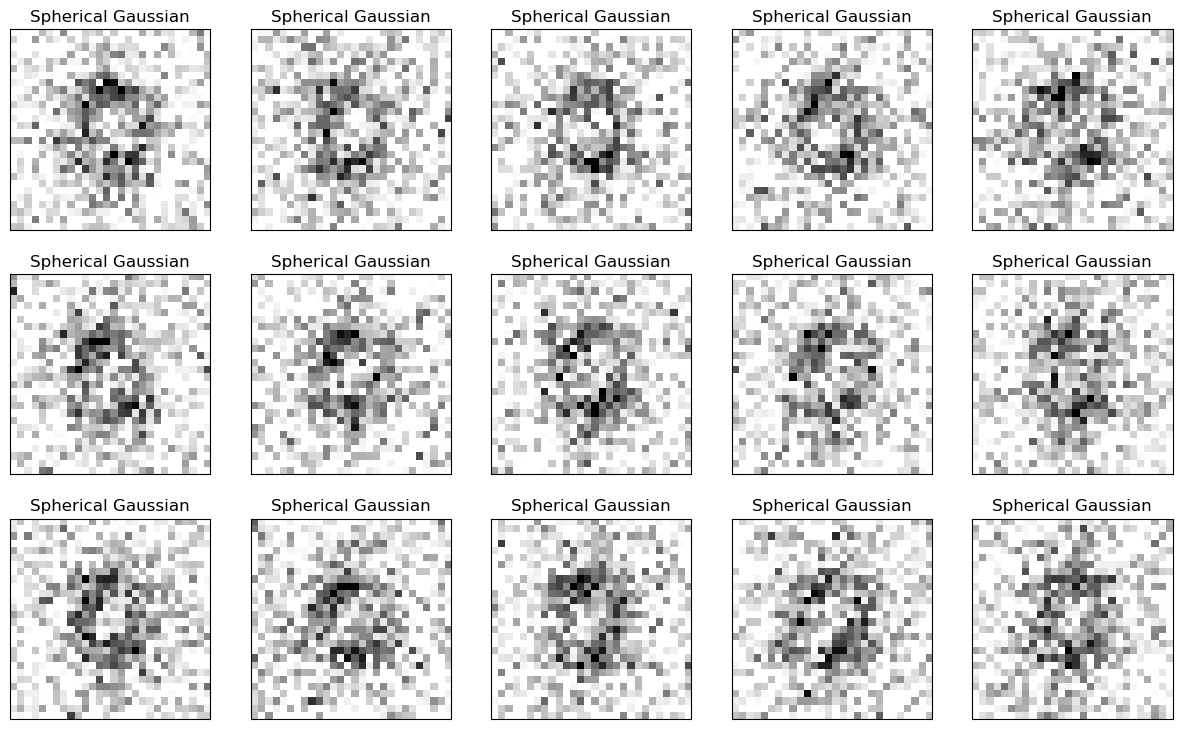

In [ ]:
### Spherical Gaussian: Cannot Model Pixel Constraints

Fitting a spherical Gaussian (variance equal in all directions, identity covariance scaled) to upright+inverted 7s produces terrible results:

**Why it fails:**
- A spherical Gaussian can ONLY generate samples where pixel values vary independently
- It's incapable of "knowing" that: "if top-right corner is black, then bottom-left must be white"
- Cannot store information about anti-correlations between different image regions
- Results in random noise with no visible digit structure

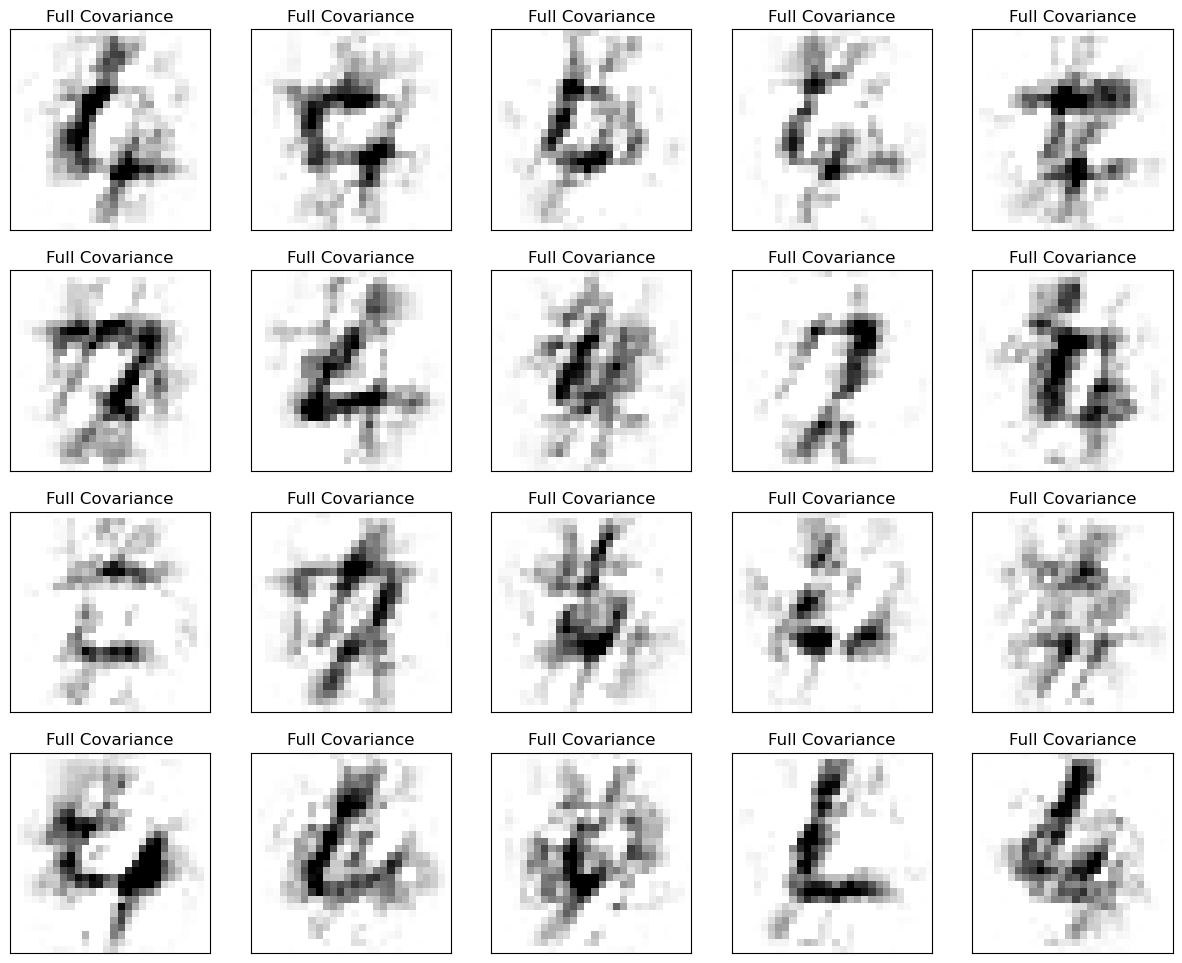

In [ ]:
### Full Gaussian: Learning Anti-Correlations

Now fit a proper Gaussian with full covariance matrix to the same mixed dataset:

**Why this dramatically improves results:**
- The covariance matrix learns: top-right and bottom-left pixels are ANTI-CORRELATED
- Generated samples are clearly either:
  - Upright 7s (top-left, top-right, bottom-right dark)
  - Inverted 7s (top-left, bottom-left, bottom-right dark)
- NO samples look like confused mixtures
- Even a SINGLE Gaussian captured the underlying structure perfectly!

**Critical insight:** Learning covariances is MORE important than adding mixture components. Structure matters!

## Part 4: Classification with Generative Models

### From Generation to Classification

So far we've built generative models that can CREATE new samples. Now we show they can also CLASSIFY!

**Key insight:** We have labels now (supervised), so we no longer need EM. Instead, train one Gaussian per class:
- Learn separate means and covariances for digits 0, 1, 2, ..., 9
- For a test image, compute likelihood under each class's Gaussian
- Pick the class with highest likelihood

**Why this works:**
- Class 0 images cluster together → separate Gaussian
- Class 9 images cluster together → separate Gaussian
- Test images have higher likelihood under their true class

### What About Accuracy?

Expected accuracy: **~85%** on MNIST

**Why not higher?**
- Pixel features are too high-dimensional (784 pixels) for limited training data
- Gaussian assumption is too restrictive for complex digit shapes
- Other methods do much better: SVMs achieve ~95%, CNNs achieve 99%+

**Why even 85% is impressive:**
- Shows that simple generative models offer USEFUL predictions
- We're using a extremely basic method (just mean and covariance per class)
- The key is that Gaussian models have nice mathematical properties, unlike black-box methods

In [ ]:
### Training Classification Models

Learn a separate Gaussian model for each digit class:
- For each digit 0-9: compute mean and covariance from training images of that digit
- Store the prior probability: P(digit=k) = count of digit k / total training samples
- Use these to build a probabilistic classifier

**Key difference from generation:** Now we USE the labels! No EM needed, just simple statistics per class.

In [ ]:
### Computing Class Likelihoods and Predictions

**Likelihood computation:**
- For each class: compute log P(x | class) 
- Using Gaussian formula: higher likelihood for test image x if x looks like training images of this class
- Add log prior: log P(class) 
- Problem: covariance matrices are often singular (determinant = 0) due to redundant features
- Solution: Use Moore-Penrose pseudoinverse (handles singular matrices gracefully)

**Prediction:**
- For each test image, compute log-likelihood under all 10 classes
- Pick the class with HIGHEST likelihood (maximum likelihood principle)
- This gives us predicted digit label

In [22]:
# Prepare test data
test_full = np.zeros((len(test_images), 28, 28))
for i in range(len(test_images)):
    test_full[i, :] = np.concatenate(test_images[i]).reshape((28, 28))

test_normalized = test_full / 256.0
test_flat = flatten_images(test_normalized)

# Make predictions
predictions = predict_class(test_flat, class_models, n_classes)
accuracy = np.sum(predictions == test_labels) / len(test_labels)

print(f"Classification Accuracy on Test Set: {accuracy:.4f}")

Classification Accuracy on Test Set: 0.8573


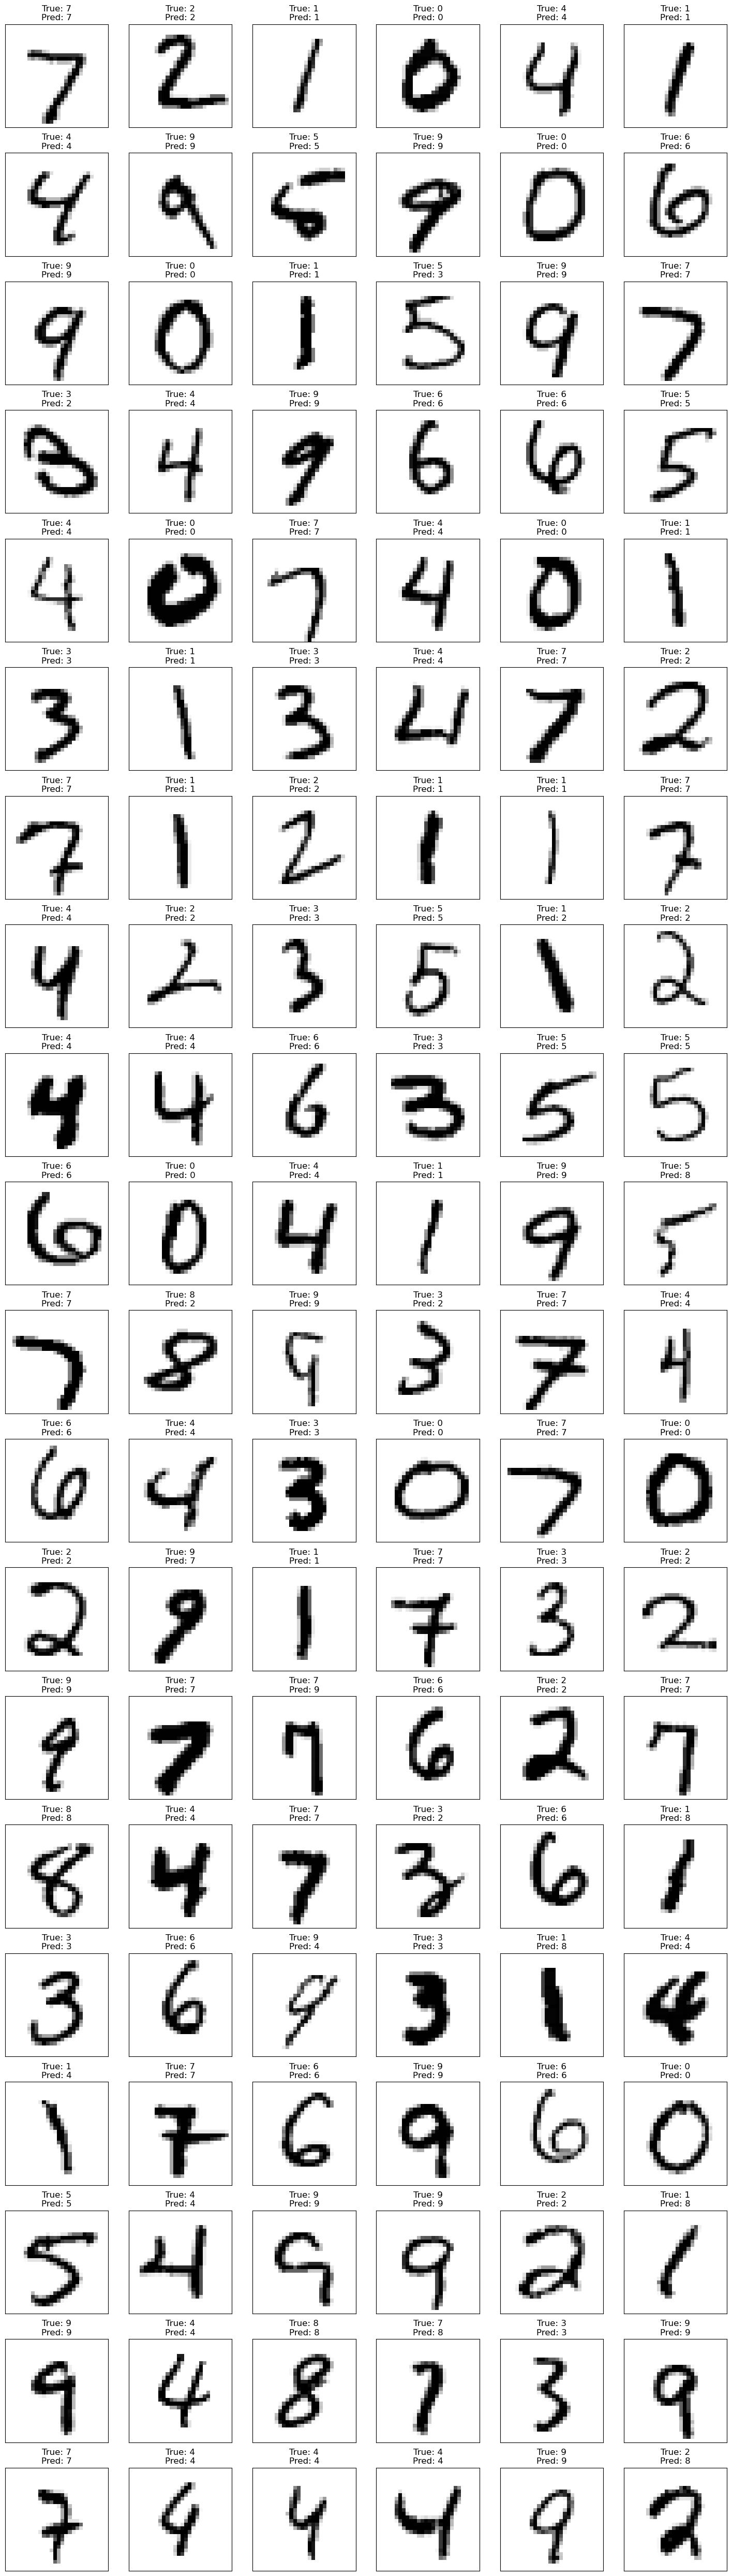

In [23]:
# Visualize predictions
display_rows, display_cols = 20, 6
fig13, axes13 = plot_utils.getFigList(display_rows, display_cols, sizey=3.2)
pred_labels = [f"True: {test_labels[i]}\nPred: {predictions[i]}" for i in range(display_rows * display_cols)]
plot_utils.showImagesNoAxes(axes13, test_flat[:display_rows*display_cols], display_rows, display_cols, 
                             resize=True, imShape=image_shape, labelList=pred_labels)

## Part 5: The Superpower of Generative Models - Handling Missing Data

### Why Generative Models Are Special

**Discriminative models (e.g., neural networks) can only classify if all features are present.**

**Generative models have a unique advantage:** They understand the full joint distribution, so they can:
1. **Classify with missing data:** Use only observed pixels to compute likelihood
2. **Reconstruct missing pixels:** Fill in censored regions with reasonable values

### The Experiment

We remove the central 21% of pixels (censoring the most important part!) and observe:

**Expected accuracy drop:** From ~85% → ~78.57%
- Losing central pixels hurts but doesn't destroy classification
- Why? Edge pixels (available) still carry useful info

**Reconstruction quality:** Blurry but recognizable
- Generative model learns: "if I see edge pixels of this shape, the center was probably..."
- Uses conditional expectation: E[missing | observed]
- Impressive because censored images look almost blank to human eye!

### Special Case: 100% Censored Images

When ALL pixels are removed, accuracy drops to ~11%. Why?
1. Model defaults to predicting digit "1" (most common class)
2. Reason: Digit 1 has high prior probability (appears most in training)
3. Also: Digit 1 is mostly white space (matches fully blank image)
4. This shows that generative models correctly learn class priors!

**Key takeaway:** Generative models gracefully degrade - they use whatever information is available (priors, observed features) to make best guess.

In [ ]:
### Classifying Images with Missing Pixels

**Key idea:** The likelihood function can work with PARTIAL observations:
- Create a boolean mask: True = pixel observed, False = pixel censored
- Modify likelihood computation to only use observed pixels
- Unobserved pixels don't contribute to the score
- The model still predicts based on available information!

**Feature mask explanation:**
- We censor the central 8x20 × 8x20 pixel region (21% of image)
- This contains the MOST IMPORTANT structural information
- Yet the model still achieves ~79% accuracy!
- Why? Edge pixels carry useful info about digit shape and orientation

Accuracy with Missing Pixels: 0.7857


In [ ]:
### Reconstructing Missing Pixels

**The reconstruction formula (Gaussian conditional expectation):**

For a Gaussian with known covariance, if we observe part of the vector, the best estimate for the missing part is:

$$E[X_{missing} | X_{observed}] = \mu_{missing} + \Sigma_{missing,observed} \cdot \Sigma_{observed}^{-1} \cdot (X_{observed} - \mu_{observed})$$

**Why this works:**
- Uses covariance structure learned during training
- If observed edge pixels suggest "this is a 7", the formula predicts what center should look like
- The reconstruction reflects class-specific digit patterns
- Results are blurry (expected - missing 21% of info) but still recognizable

**Observations:**
- Reconstructions are quite good despite losing central pixels
- Human eye: censored images seem almost uninterpretable
- Model: uses learned structure to "hallucinate" reasonable completions
- This demonstrates power of generative models!

In [ ]:
# Visualize censored images
display_rows, display_cols = 3, 6
fig14, axes14 = plot_utils.getFigList(display_rows, display_cols, sizey=3.2)
censor_labels = [f"True: {test_labels[i]}\nCensored" for i in range(display_rows * display_cols)]
plot_utils.showImagesNoAxes(axes14, test_censored_flat[:display_rows*display_cols], display_rows, display_cols, 
                             resize=True, imShape=image_shape, labelList=censor_labels)

# Visualize reconstructed images
fig15, axes15 = plot_utils.getFigList(display_rows, display_cols, sizey=3.5)
recon_labels = [f"True: {test_labels[i]}\nPred: {predictions_censored[i]}\nReconstructed" 
                for i in range(display_rows * display_cols)]
plot_utils.showImagesNoAxes(axes15, test_reconstructed[:display_rows*display_cols], display_rows, display_cols, 
                             resize=True, imShape=image_shape, labelList=recon_labels)